In [1]:
from langgraph.graph import StateGraph , START , END  
from typing import TypedDict  # used to define dictionary structures with fixed keys and types

/Users/divyanshudhyani/Documents/LANG/env/lib/python3.14/site-packages/langchain_core/_api/deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [2]:
class BatsmanState(TypedDict):
    runs: int 
    fours: int 
    sixes: int
    balls: int

    sr: float
    bpb: float
    boundary_percentage: float
    summary: str

In [3]:
def calculate_sr(state: BatsmanState) :
    sr = (state['runs']/state['balls' ])*100
    state['sr'] = sr
    return {'sr' : sr} # partial state update for parallel execution 

def calculate_bpb(state: BatsmanState) :
    bpb = state['balls']/(state['fours'] + state['sixes'])
    state['bpb'] = bpb
    return {'bpb' : bpb}
def calculate_boundary_percentage(state: BatsmanState) :
    boundary_percentage = ((state['fours'] * 4) + (state['sixes'] * 6)) / state['runs'] * 100
    state['boundary_percentage'] = boundary_percentage
    return {'boundary_percentage' : boundary_percentage}

def summary(state: BatsmanState):
    summary = f"""
    Strike Rate - {state['sr']} \n
    Balls per boundary - {state['bpb']} \n
    Boundary percent - {state['boundary_percentage']}
    """
    state['summary'] = summary 
    return {'summary' : summary}


In [4]:
graph = StateGraph(BatsmanState)
# nodes
graph. add_node(' calculate_sr', calculate_sr) 
graph. add_node(' calculate_bpb', calculate_bpb)
graph. add_node(' calculate_boundary_percent', calculate_boundary_percentage)
graph. add_node(' summary', summary)

In [5]:
# edges 
graph. add_edge(START, ' calculate_sr')
graph. add_edge(START, ' calculate_bpb')
graph. add_edge(START, ' calculate_boundary_percent')
graph. add_edge(' calculate_sr', ' summary')
graph. add_edge(' calculate_bpb', ' summary')
graph. add_edge(' calculate_boundary_percent', ' summary')
graph. add_edge(' summary', END)

workflow = graph.compile()


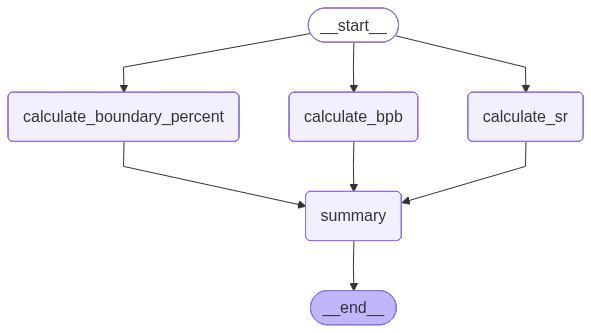

In [6]:
workflow

In [7]:

initial_state = {
    "runs": 120,
    "fours": 10,
    "sixes": 5,
    "balls": 80,
}

workflow.invoke(initial_state)


{'runs': 120,
 'fours': 10,
 'sixes': 5,
 'balls': 80,
 'sr': 150.0,
 'bpb': 5.333333333333333,
 'boundary_percentage': 58.333333333333336,
 'summary': '\n    Strike Rate - 150.0 \n\n    Balls per boundary - 5.333333333333333 \n\n    Boundary percent - 58.333333333333336\n    '}